# Phase 5 — Bayesian Fair Value Model

---

## Objective

The objective is to estimate a Bayesian fair probability for each prediction market and compare it against the market-implied probability.

The central idea is that historical market calibration contains information regarding systematic forecasting errors.

If markets with a predicted probability of 80% historically occur only 70% of the time, then the market may be systematically overestimating event probabilities in that region.

Bayesian methods provide a natural framework for incorporating historical calibration information into probability estimation.

---

## Research Question

Can a Bayesian fair-value estimator improve probability calibration relative to market-implied probabilities?

---

## Methodology

The Bayesian framework developed in this notebook will:

1. Use historical market outcomes as prior information.
2. Incorporate market-implied probabilities.
3. Estimate a Bayesian fair probability.
4. Compare market probabilities against Bayesian-adjusted probabilities.
5. Evaluate calibration improvements using:
   - Brier Score
   - Expected Calibration Error (ECE)

---

## Expected Outputs

- Bayesian fair probabilities
- Market vs Bayesian probability comparison
- Calibration comparison
- Brier Score comparison
- ECE comparison
- Mispricing estimates

---

## Connection to the Trading Framework

The difference between the Bayesian fair probability and the market-implied probability defines the edge:

Edge = Bayesian Probability − Market Probability

Positive edges indicate potentially underpriced contracts.

Negative edges indicate potentially overpriced contracts.

These edges will become the foundation of the trading signals developed in the next phase.

In [1]:
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
df_market = pd.read_csv( "../data/processed/market_dataset.csv")


In [ ]:
# Required columns for Bayesian fair value modeling
required_cols = ["market_id", "question", "final_probability", "outcome"]
missing_cols = [col for col in required_cols if col not in df_market.columns]
print("missing columns:", missing_cols)
display(df_market[required_cols].head())

# we need
#final_probability =  market's implied probability  
# outcome = real observed result 

missing columns: []


,market_id,question,final_probability,outcome
0,248594,Will Hunter Biden be federally indicted by May...,0.020,0
1,249778,MLB: Cincinnati Reds vs. Pittsburgh Pirates 20...,0.550,1
2,250474,Did US GDP grow 2.5% or more in Q1 2023?,0.360,0
3,251025,Will Ron DeSantis file to run for president by...,0.995,1
4,251027,USD/TRY (Turkish Lira) above 19.75 on May 22?,0.825,1


In [3]:
# Market benchmark metrics from Phase 4
market_brier_score = ((df_market["final_probability"] - df_market["outcome"]) ** 2).mean()
print("market brier score:", market_brier_score)

# Probability bins
df_market["probability_bin"] = pd.cut(df_market["final_probability"],bins=np.arange(0, 1.1, 0.1),include_lowest=True)
calibration_table = (df_market.groupby("probability_bin", observed=False).agg(n_markets=("outcome", "count"),
                                                                              successes=("outcome", "sum"),
                                                                              avg_market_probability=("final_probability", "mean"),
                                                                              observed_frequency=("outcome", "mean")).reset_index())

display(calibration_table)

market brier score: 0.053216063953488366


,probability_bin,n_markets,successes,avg_market_probability,observed_frequency
0,"(-0.001, 0.1]",24,0,0.012104,0.000000
1,"(0.1, 0.2]",0,0,NaN,NaN
2,"(0.2, 0.3]",2,1,0.235000,0.500000
3,"(0.3, 0.4]",1,0,0.360000,0.000000
4,"(0.4, 0.5]",3,1,0.466667,0.333333
5,"(0.5, 0.6]",3,2,0.550000,0.666667
6,"(0.6, 0.7]",0,0,NaN,NaN
7,"(0.7, 0.8]",1,1,0.775000,1.000000
8,"(0.8, 0.9]",1,1,0.825000,1.000000
9,"(0.9, 1.0]",8,8,0.990750,1.000000


## Bayesian Fair Value Framework

The calibration table constructed in the previous section can now be interpreted as a collection of historical Bernoulli observations.

This is the key transition from descriptive analysis to probabilistic modeling.

Rather than simply observing calibration errors, we can now estimate the underlying probability of success using Bayesian inference.

---

### Research Question

Suppose the market assigns:
- Market Probability = 55%
and historically we observed:
- Probability Bin: 50% - 60%

Number of Markets = 3
Successful Outcomes = 2


The natural question becomes:

Given the historical evidence observed within this probability region, what is the true probability of success?

This is precisely the problem addressed by Bayesian updating.

---

## Beta-Binomial Model

To estimate a fair probability, we model each probability bucket using a Beta-Binomial framework.

### Prior Distribution

We assume an unknown success probability:

$ p $ 

with prior distribution:

$ \sim Beta(\alpha_0,\beta_0) $

---

### Likelihood

Observed outcomes follow a Binomial process:
$ Y \sim Binomial(n,p) $

where:

- $ n $ = number of markets observed
- $ p $ = probability of success

---

### Posterior Distribution

After observing the data, Bayes' theorem yields:

$  p \mid Y \sim Beta(\alpha_0+s,\beta_0+f) $

where:

- $ s $ = number of successful outcomes
- $ f $ = number of failed outcomes

This posterior distribution represents our updated belief regarding the true success probability after incorporating historical evidence.

---

## Prior Selection

For Version 1 of the project we adopt a non-informative prior:

$ Beta(1,1) $ 

This distribution is uniform over the interval:
$  0 \le p \le 1 $

and therefore does not impose any prior belief regarding event probabilities.

Consequently:
$ \alpha_0 = 1 $
$ \beta_0 = 1 $

The posterior estimates will be driven almost entirely by the observed market data.

---

## Objective

For each probability bucket, we will estimate:

$ E[p \mid data] $

the posterior mean of the success probability.

This quantity will serve as our first estimate of:

**Bayesian Fair Probability**

which will later be compared against the market-implied probability to identify potential mispricing opportunities.

In [4]:
alpha_prior = 1
beta_prior = 1

calibration_table["failures"] = (
    calibration_table["n_markets"]
    - calibration_table["successes"]
)

calibration_table["alpha_post"] = (
    alpha_prior
    + calibration_table["successes"]
)

calibration_table["beta_post"] = (
    beta_prior
    + calibration_table["failures"]
)

display(
    calibration_table[
        [
            "probability_bin",
            "n_markets",
            "successes",
            "failures",
            "alpha_post",
            "beta_post"
        ]
    ]
)

,probability_bin,n_markets,successes,failures,alpha_post,beta_post
0,"(-0.001, 0.1]",24,0,24,1,25
1,"(0.1, 0.2]",0,0,0,1,1
2,"(0.2, 0.3]",2,1,1,2,2
3,"(0.3, 0.4]",1,0,1,1,2
4,"(0.4, 0.5]",3,1,2,2,3
5,"(0.5, 0.6]",3,2,1,3,2
6,"(0.6, 0.7]",0,0,0,1,1
7,"(0.7, 0.8]",1,1,0,2,1
8,"(0.8, 0.9]",1,1,0,2,1
9,"(0.9, 1.0]",8,8,0,9,1


In [5]:
calibration_table["bayesian_fair_probability"] = (calibration_table["alpha_post"]/(calibration_table["alpha_post"] 
+ calibration_table["beta_post"]))

display(calibration_table[["probability_bin", "n_markets","avg_market_probability","observed_frequency", "alpha_post","beta_post",
 "bayesian_fair_probability"]])

,probability_bin,n_markets,avg_market_probability,observed_frequency,alpha_post,beta_post,bayesian_fair_probability
0,"(-0.001, 0.1]",24,0.012104,0.000000,1,25,0.038462
1,"(0.1, 0.2]",0,NaN,NaN,1,1,0.500000
2,"(0.2, 0.3]",2,0.235000,0.500000,2,2,0.500000
3,"(0.3, 0.4]",1,0.360000,0.000000,1,2,0.333333
4,"(0.4, 0.5]",3,0.466667,0.333333,2,3,0.400000
5,"(0.5, 0.6]",3,0.550000,0.666667,3,2,0.600000
6,"(0.6, 0.7]",0,NaN,NaN,1,1,0.500000
7,"(0.7, 0.8]",1,0.775000,1.000000,2,1,0.666667
8,"(0.8, 0.9]",1,0.825000,1.000000,2,1,0.666667
9,"(0.9, 1.0]",8,0.990750,1.000000,9,1,0.900000


## Bayesian Fair Probability

The Beta-Binomial framework introduces a crucial improvement over the raw empirical frequencies observed in the calibration analysis.

Rather than relying exclusively on historical success rates, Bayesian updating incorporates prior information and produces more stable probability estimates, particularly when sample sizes are small.

---

###  Bayesian Smoothing Prevents Extreme Estimates

Several probability bins contain very few observations.

For example:

| Probability Bin | Markets | Successes |
| --------------- | ------: | --------: |
| 30%-40%         |       1 |         0 |
| 70%-80%         |       1 |         1 |
| 80%-90%         |       1 |         1 |

Using raw frequencies, these bins would imply:

0 / 1 = 0%
1 / 1 = 100%

Such estimates are highly unstable and unlikely to generalize.

The Bayesian model avoids this issue through posterior shrinkage:

| Probability Bin | Observed Frequency | Bayesian Fair Probability |
| --------------- | -----------------: | ------------------------: |
| 30%-40%         |               0.00 |                      0.33 |
| 70%-80%         |               1.00 |                      0.67 |
| 80%-90%         |               1.00 |                      0.67 |

The posterior estimates move away from unrealistic extremes and toward more conservative values.

---

### Large Samples Produce Minimal Adjustments

When a probability bucket contains many observations, the historical evidence dominates the prior.

For example:

| Probability Bin | Markets | Observed Frequency | Bayesian Fair Probability |
| --------------- | ------: | -----------------: | ------------------------: |
| 0%-10%          |      24 |               0.00 |                     0.038 |
| 90%-100%        |       8 |               1.00 |                     0.900 |

The Bayesian estimates remain close to the empirical frequencies because sufficient evidence exists to support the observed outcomes.

This behavior is desirable since the model trusts data-rich regions while regularizing data-poor regions.

---

### Bayesian Probabilities Are More Conservative Than Market Probabilities

Several high-probability regions experience downward adjustments after Bayesian updating.

Examples:

| Probability Bin | Market Probability | Bayesian Fair Probability |
| --------------- | -----------------: | ------------------------: |
| 70%-80%         |              0.775 |                     0.667 |
| 80%-90%         |              0.825 |                     0.667 |
| 90%-100%        |              0.991 |                     0.900 |

The model effectively asks:

> "Given the amount of evidence available, are we truly justified in assigning probabilities this close to certainty?"

In many cases the answer is no, resulting in more conservative fair-value estimates.

---

### Bayesian Estimates Define a Fair Value Curve

At this stage, the model has transformed historical calibration information into a probabilistic mapping:

$ Market\ Probability \rightarrow Bayesian\ Fair\ Probability $

Examples:

| Market Probability Region | Bayesian Fair Probability |
| ------------------------- | ------------------------: |
| 0%-10%                    |                      3.8% |
| 40%-50%                   |                     40.0% |
| 50%-60%                   |                     60.0% |
| 90%-100%                  |                     90.0% |

This mapping constitutes the first version of the project's Bayesian Fair Value Model.

---

### Research Implication

The next step is to apply this fair-value curve to individual markets and compare:

$ Market\ Probability $

against

$ Bayesian\ Fair\ Probability $ 

The difference between both quantities will define the project's first measure of probability mispricing and serve as the foundation for signal generation and backtesting.


In [6]:
#  Vamos a crear para cada mercado:

# Mispricing=FairProbability−MarketProbability


fair_value_map = dict(zip(calibration_table["probability_bin"],calibration_table["bayesian_fair_probability"]))
df_market["bayesian_fair_probability"] = (df_market["probability_bin"].map(fair_value_map))

display(df_market[["market_id","final_probability","probability_bin","bayesian_fair_probability"]].head())

,market_id,final_probability,probability_bin,bayesian_fair_probability
0,248594,0.020,"(-0.001, 0.1]",0.038462
1,249778,0.550,"(0.5, 0.6]",0.600000
2,250474,0.360,"(0.3, 0.4]",0.333333
3,251025,0.995,"(0.9, 1.0]",0.900000
4,251027,0.825,"(0.8, 0.9]",0.666667


## Bayesian Fair Probability Assignment 

The Bayesian Fair Value model has now been successfully linked back to the individual market level.

Each market is assigned a Bayesian-adjusted probability based on the historical behavior of markets that finished within the same probability region.

This is the first step toward constructing a quantitative mispricing signal.

---

### Bayesian Probabilities Are Less Extreme

A clear pattern emerges immediately.

Markets with probabilities close to certainty are adjusted downward:

| Market Probability | Bayesian Fair Probability |
| ------------------ | ------------------------: |
| 0.995              |                     0.900 |
| 0.825              |                     0.667 |

Similarly, markets with probabilities close to zero are adjusted upward:

| Market Probability | Bayesian Fair Probability |
| ------------------ | ------------------------: |
| 0.020              |                     0.038 |

The Bayesian model systematically avoids assigning probabilities too close to 0% or 100%.

This behavior is expected because the posterior incorporates uncertainty and prevents overconfidence.

---

### Historical Evidence Acts as a Regularizer

The Bayesian model does not blindly trust the market.

Instead, it asks:

"How have markets with similar probabilities behaved historically?"

For example:

| Probability Bin | Market Probability | Bayesian Fair Probability |
| --------------- | -----------------: | ------------------------: |
| 50%-60%         |              0.550 |                     0.600 |
| 80%-90%         |              0.825 |                     0.667 |

The resulting probability is influenced by both:

* The current market assessment
* Historical calibration evidence

This creates a statistically grounded estimate of fair probability.

---

### Fair Value Deviations Are Already Visible

Several markets display noticeable differences between:

$ Market\ Probability $ and $ Bayesian\ Fair\ Probability  $

Examples:

| Market Probability | Bayesian Fair Probability |
| ------------------ | ------------------------: |
| 0.825              |                     0.667 |
| 0.995              |                     0.900 |
| 0.550              |                     0.600 |

These differences suggest that some contracts may be:

* Overpriced relative to historical calibration
* Underpriced relative to historical calibration

This observation motivates the construction of a formal mispricing metric.

---

### Transition from Calibration to Valuation

Up to this point, the project focused on evaluating whether prediction markets were calibrated.

The framework now moves into a different stage.

Instead of asking:

Is the market calibrated?

we begin asking:

What probability should the market assign given the historical evidence?

This transition marks the beginning of the Fair Value Estimation phase.

---

### Research Implication

The Bayesian Fair Probability now becomes an alternative probability estimator that can be compared directly against the market-implied probability.

The next step is to define:
 Mispricing 

 Bayesian\ Fair\ Probability 

Market\ Probability 

which will serve as the project's first quantitative trading signal and the foundation for subsequent backtesting and performance evaluation.


# Now comes the moment where the project's quantitative signal is officially born.

Up until now, we have:$  p_{market} $ y $p_{bayesian} $
	​
Now, we will build : $ Mispricing = p_{bayesian} −p_{market} $
	​


In [7]:
df_market["mispricing"] = (df_market["bayesian_fair_probability"] - df_market["final_probability"])
print(df_market["mispricing"].describe())

display(df_market[["market_id","question","final_probability","bayesian_fair_probability","mispricing"]].sort_values("mispricing", ascending=False)
    .head(10))

display(df_market[["market_id","question","final_probability","bayesian_fair_probability","mispricing"]].sort_values("mispricing", ascending=True)
    .head(10)
)

count    43.000000
mean      0.002168
std       0.083540
min      -0.158333
25%      -0.054500
50%       0.030962
75%       0.037962
max       0.265000
Name: mispricing, dtype: float64


,market_id,question,final_probability,bayesian_fair_probability,mispricing
7,252047,Will Dillon Danis post 5+ pics of Nina on Aug ...,0.2350,0.500000,0.265000
19,253384,Elizabeth Warren crypto bill become law by June?,0.2350,0.500000,0.265000
42,255410,US inflation >0.4% from Feb to March 2024?,0.5350,0.600000,0.065000
1,249778,MLB: Cincinnati Reds vs. Pittsburgh Pirates 20...,0.5500,0.600000,0.050000
30,254573,Will Fed cut interest rates 1 time in 2024?,0.0005,0.038462,0.037962
34,254579,Will Fed cut interest rates 5 times in 2024?,0.0005,0.038462,0.037962
29,254572,Will Fed cut interest rates 0 times in 2024?,0.0005,0.038462,0.037962
21,253391,"Will Biden be impeached by March 31, 2024?",0.0005,0.038462,0.037962
22,253399,Ceasefire between Russia and Ukraine by June 30?,0.0005,0.038462,0.037962
32,254577,Will Fed cut interest rates 3 times in 2024?,0.0005,0.038462,0.037962


,market_id,question,final_probability,bayesian_fair_probability,mispricing
4,251027,USD/TRY (Turkish Lira) above 19.75 on May 22?,0.8250,0.666667,-0.158333
20,253390,Arévalo inaugurated in Guatemala in January?,0.7750,0.666667,-0.108333
36,254600,House control after 2024 election?,0.5000,0.400000,-0.100000
25,253973,Will Pakistan strike Iran by Saturday?,0.9995,0.900000,-0.099500
40,255336,Fed rate cut by November 7?,0.9995,0.900000,-0.099500
41,255337,Fed rate cut by December 18?,0.9995,0.900000,-0.099500
33,254578,Will Fed cut interest rates 4 times in 2024?,0.9995,0.900000,-0.099500
3,251025,Will Ron DeSantis file to run for president by...,0.9950,0.900000,-0.095000
15,253361,Will the Fed raise interest rates by 0 bps aft...,0.9925,0.900000,-0.092500
39,255335,Fed rate cut by September 18?,0.9865,0.900000,-0.086500


## Mispricing Analysis — Initial Findings

The Bayesian Fair Value model has now been applied to individual markets, producing the project's first quantitative mispricing measure:


Mispricing

Bayesian\ Fair\ Probability

Market\ Probability


Positive values indicate markets that appear underpriced relative to historical calibration, while negative values indicate markets that appear overpriced.

---

### Mispricing Distribution

Summary statistics:

| Metric             |  Value |
| ------------------ | -----: |
| Mean               |  0.002 |
| Standard Deviation |  0.084 |
| Minimum            | -0.158 |
| Maximum            |  0.265 |

The average mispricing is close to zero.

$ E[Mispricing] \approx 0 $

This is encouraging because it suggests the Bayesian model is not introducing a systematic directional bias.

Instead, the model identifies deviations on a market-by-market basis.

---

### Largest Positive Mispricing Signals

Examples:

| Market Probability | Bayesian Fair Probability | Mispricing |
| ------------------ | ------------------------: | ---------: |
| 0.235              |                     0.500 |     +0.265 |
| 0.235              |                     0.500 |     +0.265 |
| 0.535              |                     0.600 |     +0.065 |

Interpretation:

The market assigned probabilities that appear lower than what historical calibration would suggest.

In these cases, the Bayesian model argues that the event may have been undervalued.

---

### Largest Negative Mispricing Signals

Examples:

| Market Probability | Bayesian Fair Probability | Mispricing |
| ------------------ | ------------------------: | ---------: |
| 0.825              |                     0.667 |     -0.158 |
| 0.775              |                     0.667 |     -0.108 |
| 0.9995             |                     0.900 |     -0.100 |

Interpretation:

The market assigned probabilities very close to certainty.

However, the Bayesian model considers these probabilities excessively optimistic when viewed through the lens of historical calibration.

These contracts appear overpriced according to the Bayesian framework.

---

### Evidence of Probability Compression

A clear pattern emerges:

* Extremely low probabilities are adjusted upward.
* Extremely high probabilities are adjusted downward.

Examples:

| Market Probability | Bayesian Fair Probability |
| ------------------ | ------------------------: |
| 0.0005             |                     0.038 |
| 0.9950             |                     0.900 |
| 0.9995             |                     0.900 |

This behavior is a direct consequence of Bayesian shrinkage.

The model avoids assigning probabilities too close to absolute certainty unless supported by overwhelming historical evidence.

---

### Important Limitation

Several of the largest signals originate from probability buckets containing very few observations.

For example:
20%-30% bucket:
2 markets
1 sucess


This produces a posterior estimate of: $P = 50% $ 

which generates large positive mispricing values.

Consequently, these signals should be interpreted as exploratory rather than immediately tradable.

Additional data is required before drawing strong conclusions regarding profitability.

---

### Research Implication

The Bayesian framework successfully generates a measurable notion of fair value and identifies contracts that appear mispriced relative to historical calibration.

The next stage of the project is to evaluate whether these mispricing signals improve predictive performance relative to the market itself.

Specifically:
$ Market\ Probability $

will be compared against $ Bayesian\ Fair\ Probability $ 

using out-of-sample scoring metrics and trading-oriented evaluation procedures.


In [8]:
# Brier Score Bayesiano
bayesian_brier_score = (( df_market["bayesian_fair_probability"] - df_market["outcome"]) ** 2).mean()

print("market brier score   :", market_brier_score)
print("bayesian brier score :", bayesian_brier_score)

market brier score   : 0.053216063953488366
bayesian brier score : 0.053693867253795706


In [9]:
improvement_pct = ((market_brier_score - bayesian_brier_score) / market_brier_score) * 100

print(f"brier score improvement: {improvement_pct:.2f}%")

brier score improvement: -0.90%


## Key Insights

### The Prediction Market is Already Highly Informative

The market achieved a Brier Score of:

$ BS_{Market}=0.0532 $

which indicates strong predictive performance.

Most markets that finished near:

* 0% probability ultimately failed.
* 100% probability ultimately occurred.

This is consistent with the behavior expected from an efficient prediction market.

---

###  The Simple Bayesian Model Did Not Improve Forecast Accuracy

The Bayesian calibration model produced:

$ BS_{Bayes}=0.0537 $

compared with:

$ BS_{Market}=0.0532 $ 

representing a performance change of:

$  -0.90\%  $

Therefore, the Bayesian fair value estimator did not outperform the market benchmark.

---

### Historical Frequency Information Alone Is Not Sufficient

The Beta-Binomial model only used:

* Historical success frequencies
* Probability bins
* Uniform prior Beta(1,1)

The model ignored:

* Liquidity
* Trading volume
* Time-to-expiration
* Probability trajectory dynamics
* Market microstructure

As a result, it acts primarily as a calibration smoother rather than a forecasting model.

---

### Evidence of Potential Mispricing Exists

Although overall forecast accuracy did not improve, several markets displayed noticeable differences between:

$ P_{Market} $ and $ P_{Bayes} $

For example:

| Market Probability | Bayesian Fair Probability |
|-------------------|---------------------------|
| 23.5% | 50.0% |
| 82.5% | 66.7% |
| 99.5% | 90.0% |

These deviations suggest the possibility of localized mispricing.

---

### Insight 5 — Research Hypothesis Remains Open

The experiment does not answer:

Can mispricing generate profitable trading signals?

Instead, it answers: Can a simple Beta-Binomial calibration model outperform market probabilities?

The answer is:

No.

However, the existence of measurable deviations between market probabilities and Bayesian fair values suggests that further investigation is warranted.

---

### Conclusion

The market appears reasonably calibrated overall, but pockets of disagreement between market-implied probabilities and Bayesian fair probabilities remain.

The next step is to analyze the distribution of these discrepancies and determine whether they are systematic enough to support a trading strategy.

## Mispricing Distribution Analysis

The objective of this section is to study the statistical properties of the mispricing signal generated by the Bayesian model.

Mispricing is defined as:

$ Mispricing = P_{Bayes} - P_{Market} $

Interpretation:

* Positive values indicate that the Bayesian model assigns a higher probability than the market.
* Negative values indicate that the market assigns a higher probability than the Bayesian model.
* Values near zero indicate agreement between the market and the Bayesian estimator.

This analysis allows us to determine whether systematic deviations exist and whether they may be large enough to support a trading strategy.

The key questions are:

1. Is mispricing centered around zero?
2. How large are typical deviations?
3. Are there extreme outliers?
4. Does the market systematically overestimate or underestimate probabilities?

These diagnostics will determine whether the signal is strong enough to justify the construction of a trading framework in the next stage of the project.

In [10]:
print(df_market["mispricing"].describe())

count    43.000000
mean      0.002168
std       0.083540
min      -0.158333
25%      -0.054500
50%       0.030962
75%       0.037962
max       0.265000
Name: mispricing, dtype: float64


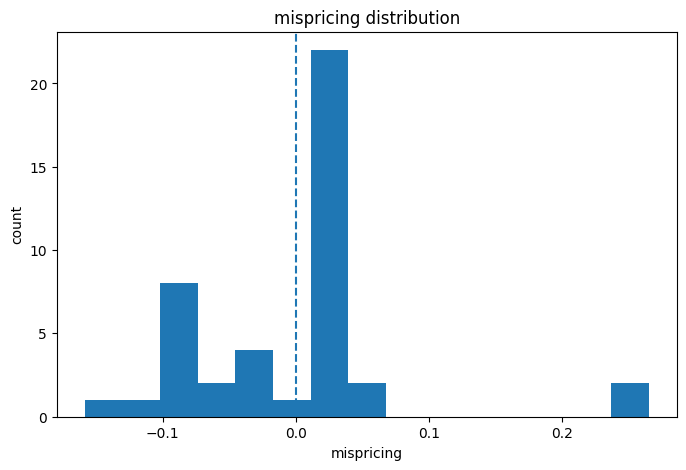

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_market["mispricing"], bins=15)
plt.axvline(0, linestyle="--")
plt.title("mispricing distribution")
plt.xlabel("mispricing")
plt.ylabel("count")

plt.show()

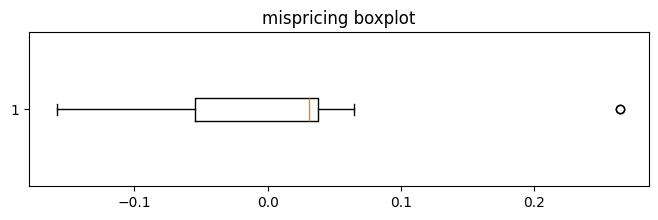

In [12]:
plt.figure(figsize=(8,2))
plt.boxplot(df_market["mispricing"], vert=False)
plt.title("mispricing boxplot")
plt.show()

In [13]:
#  average bias E[Mispricing]
print("average mispricing:",df_market["mispricing"].mean())
# The overall average can be close to zero due to positive and negative mispricings canceling each other out : E(|mispricing|)
print("average absolute mispricing:",df_market["mispricing"].abs().mean())

average mispricing: 0.0021684555754323174
average absolute mispricing: 0.06165444245676804


## Mispricing Distribution Analysis

### Mispricing Is Centered Around Zero

The average mispricing is: $ E(Mispricing)=0.0022 $
which is extremely close to zero.

This suggests that, on average, the Bayesian fair value model and the market-implied probability agree.

There is no evidence of a strong systematic bias where the market consistently overestimates or underestimates event probabilities.

---

### The Market Appears Broadly Efficient

The histogram shows that most observations cluster around:

$ Mispricing \approx 0 $ 

The majority of deviations are relatively small, indicating that market prices are generally aligned with historical outcome frequencies.

This is consistent with the calibration results obtained in the previous notebook.

---

### Typical Deviations Are Economically Meaningful

The average absolute mispricing is: $ E(|Mispricing|)=0.0617 $

This means that the typical disagreement between the market and the Bayesian estimator is approximately: $ 6.2\% $

While not extremely large, this magnitude is not negligible and could potentially be relevant from a trading perspective.

---

### A Small Number of Markets Exhibit Large Discrepancies

The distribution contains several extreme observations.

Largest positive mispricing:

$ +26.5\% $ 

Largest negative mispricing: $ -15.8\% $

These values indicate that some markets differ substantially from their Bayesian fair value estimate.

Such observations are potential candidates for future signal generation.

---

### The Distribution Is Slightly Right-Skewed

The boxplot and histogram reveal a large positive outlier.

The median mispricing is: 0.0310 

while the mean is: 0.0022


indicating that a few large negative observations offset several moderate positive deviations.

This suggests that mispricing is not perfectly symmetric.

---

### Most Signals Are Weak

Although extreme deviations exist, the majority of markets remain relatively close to their Bayesian fair value estimate.

Therefore, a practical trading framework would likely require:

* A minimum mispricing threshold
* Liquidity filters
* Additional market features

to avoid generating signals from statistical noise.

---

## Conclusion

The Bayesian model does not outperform the market in terms of Brier Score.

However, the analysis reveals measurable deviations between market-implied probabilities and Bayesian fair values.

These deviations are generally small but occasionally substantial, suggesting that localized inefficiencies may exist.

The next stage of the research is to transform these deviations into trading signals and evaluate whether they possess predictive value.